# 🏦 Buy & Hold Strategy  
*"Time in the market beats timing the market"*

## 📊 Strategy Overview
**Buy & Hold** — классическая долгосрочная инвестиционная стратегия, основанная на принципах:
- 🕰 Долгосрочного владения активами
- 📈 Участия в фундаментальном росте рынка
- 🛡 Защиты от эмоциональных решений

In [34]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px


# 1. Buy & Hold Strategy: Classic Investment Approach

## 📌 Core Concept
**"Buy & Hold"** — фундаментальная стратегия пассивного инвестирования, где:
- ✔ Вы покупаете актив **один раз**
- ✔ Держите его **долгосрочно** (5+ лет)
- ✔ Продаете при достижении целей

## 1.1 Подготовка данных

In [35]:
silv = pd.read_csv('data/SILV.txt') # загружаем датафрейм

In [36]:
def good_dataframe(data):
  """Преобразует сырые рыночные данные в чистый DataFrame с правильными типами и индексом времени
    
    Подготавливает данные для технического анализа.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['<TICKER>', '<PER>', '<DATE>', '<TIME>', '<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', '<VOL>']
            
    Returns:
        tuple: Возвращает кортеж из двух DataFrame:
            - Основной DataFrame с индексом времени
            - Копия DataFrame для безопасного резервирования
            
    Processing Logic:
        1. Удаление избыточных столбцов
        2. Переименование столбцов в human-friendly формат
        3. Преобразование типов данных
        4. Создание правильного временного индекса
    """
  # 1. Удаляем ненужные столбцы (тикер и период не нужны для анализа)
  data.drop(['<TICKER>', '<PER>'], inplace=True, axis=1)
    
  # 2. Переименовываем столбцы для удобства работы
  data.columns = ['date', 'time', 'open', 'high', 'low', 'close', 'volume']
    
  # 3. Преобразуем дату из формата YYYYMMDD в datetime
  data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
    
  # 4. Обрабатываем время (HHMMSS -> datetime.time)
  data['time'] = pd.to_datetime(data['time'], format='%H%M%S').dt.time
    
  # 5. Комбинируем дату и время в единую метку времени
  data['time'] = pd.to_datetime(
        data['date'].astype('str') + ' ' + data['time'].astype('str'))
    
  # 6. Удаляем отдельный столбец даты (теперь он в индексе)
  data.drop(['date'], inplace=True, axis=1)
    
  # 7. Устанавливаем комбинированную метку времени как индекс
  data = data.set_index('time')
    
  # 8. Создаем резервную копию для безопасного использования
  data_copy = data.copy()
  
  return data, data_copy

silv_df_1m, silv_df__1m_copy = good_dataframe(silv) # Получаем новый датафрейм и его копию


In [37]:
def new_timeframe(data, timeframe):
    """Преобразует минутные данные (1М) в указанный временной интервал, сохраняя структуру OHLCV-данных.
    
    Использует принципы агрегации свечных данных:
    - Open - первое значение периода
    - High - максимум периода
    - Low - минимум периода
    - Close - последнее значение периода
    - Volume - сумма объема за период

    Args:
        data (pd.DataFrame): Исходный DataFrame с 1-минутными данными, 
                            должен содержать колонки ['open', 'high', 'low', 'close', 'volume']
                            и иметь DateTimeIndex
        timeframe (str): Желаемый таймфрейм из списка доступных:
                        ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']

    Returns:
        pd.DataFrame: Новый DataFrame с преобразованными данными в указанном таймфрейме
        
    Raises:
        ValueError: Если передан неподдерживаемый timeframe
    """
    
    # 5-минутный таймфрейм (основной для внутридневной торговли)
    if timeframe == '5 min':
        data_5m = data.resample('5min').agg({
            'open': 'first',   # Первая цена в 5-минутном интервале
            'high': 'max',     # Максимум за 5 минут
            'low': 'min',      # Минимум за 5 минут
            'close': 'last',   # Последняя цена в интервале
            'volume': 'sum'   # Суммарный объем
        }).dropna()           # Удаление пустых интервалов
        return data_5m
        
    # 15-минутный таймфрейм (популярен у свинг-трейдеров)
    elif timeframe == '15 min':
        data_15m = data.resample('15min').agg({
            'open': 'first',  # Сохраняем структуру свечи
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'   # Агрегируем объем
        }).dropna()
        return data_15m
        
    # 30-минутный таймфрейм (используется для анализа среднесрочных тенденций)
    elif timeframe == '30 min':
        data_30m = data.resample('30min').agg({
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()
        return data_30m

    # 1-часовой таймфрейм (стандарт для многих торговых стратегий)
    elif timeframe == '1h':
        data_1H = data.resample('1h').agg({
            'open': 'first',  # Важно для определения гэпов
            'high': 'max',    # Уровни сопротивления
            'low': 'min',     # Уровни поддержки
            'close': 'last',   # Ключевое значение для индикаторов
            'volume': 'sum'   # Ликвидность периода
        }).dropna()
        return data_1H
        
    # 2-часовой таймфрейм (используется для анализа азиатской/европейской сессий)
    elif timeframe == '2h':
        data_2H = data.resample('2h').agg({
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()
        return data_2H
        
    # 4-часовой таймфрейм (золотой стандарт для Forex-трейдеров)
    elif timeframe == '4h':
        data_4H = data.resample('4h').agg({
            'open': 'first',  # Особенно важен для открытия лондонской сессии
            'high': 'max',
            'low': 'min',
            'close': 'last',  # Закрытие американской сессии
            'volume': 'sum'
        }).dropna()
        return data_4H

    # Дневной таймфрейм (для долгосрочных инвесторов)
    elif timeframe == 'D':
        data_D = data.resample('D').agg({
            'open': 'first',  # Цена открытия дня
            'high': 'max',    # Дневной максимум
            'low': 'min',     # Дневной минимум
            'close': 'last', # Важно для закрытия позиций
            'volume': 'sum'  # Общая дневная ликвидность
        }).dropna()
        return data_D
silv_4H = new_timeframe(silv_df_1m, '4h') # Создаем датафрейм с периодом 4 часа
silv_4H

,open,high,low,close,volume
time,,,,,
2009-01-11 12:00:00,11.34,11.34,11.34,11.34,1
2009-01-11 16:00:00,11.20,11.20,11.00,11.00,2
2009-01-12 08:00:00,11.30,11.30,11.17,11.20,30
2009-01-12 12:00:00,11.19,11.29,11.19,11.22,53
2009-01-12 16:00:00,11.11,11.11,10.88,11.08,359
...,...,...,...,...,...
2025-06-27 20:00:00,36.85,36.87,36.58,36.67,18730
2025-06-30 08:00:00,36.77,36.97,36.77,36.87,34524
2025-06-30 12:00:00,36.87,36.88,36.58,36.76,34808


## 1.2 Реализация стратегии

Начальные инвестиции: 1,000,000 руб
Конечная стоимость: 3,247,795 руб
Общая доходность: 224.78%
Среднегодовая доходность: 7.64%


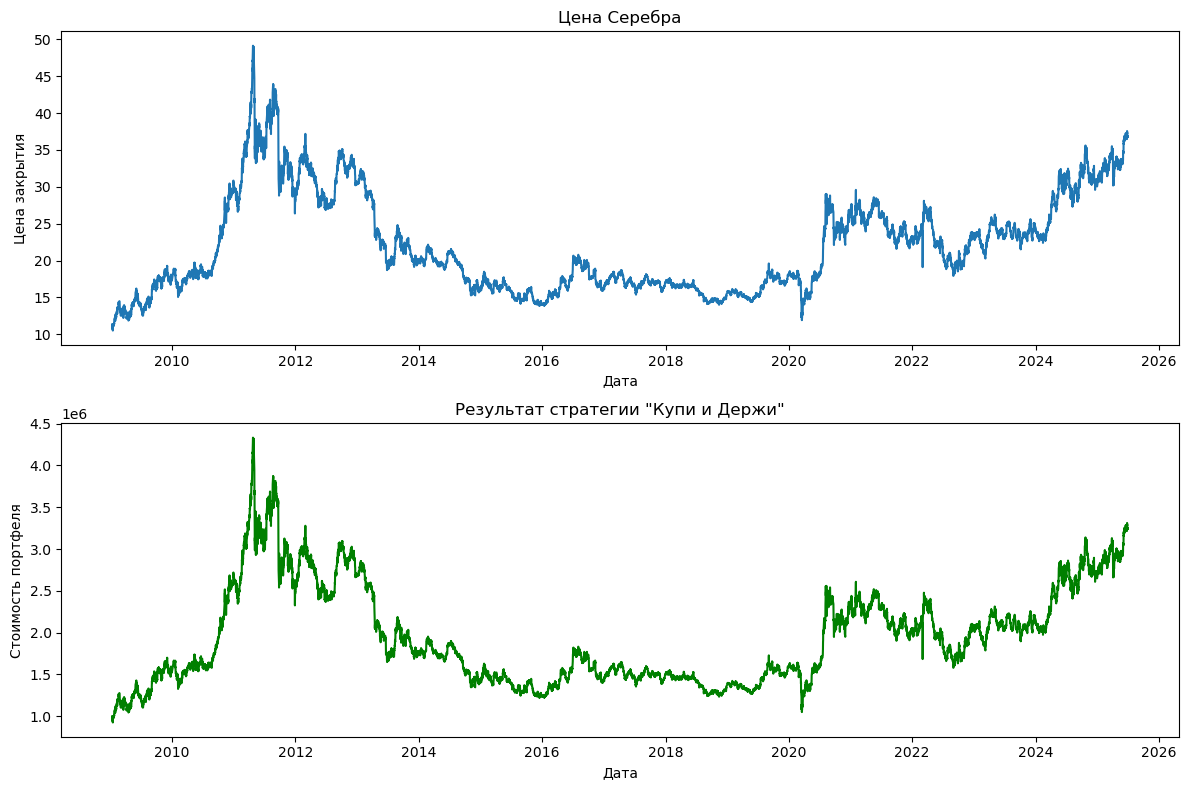

In [38]:
initial_investment = 1_000_000 # Начальная инвестиция
silv_4H['Shares'] = initial_investment / silv_4H['close'].iloc[0] # Количество купленных акций
silv_4H['Portfolio_Value'] = silv_4H['Shares'] * silv_4H['close'] # Стоимость портфеля
silv_4H['Daily_Return'] = silv_4H['close'].pct_change() # Дневная доходность
silv_4H['Cumulative_Return'] = (1 + silv_4H['Daily_Return']).cumprod() # Кумулятивная доходность

# Визуализация стратегии
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

axes[0].plot(
    silv_4H.index,
    silv_4H['close'])

axes[0].set_title('Цена Серебра')
axes[0].set_ylabel('Цена закрытия')
axes[0].set_xlabel('Дата')

axes[1].plot(
    silv_4H.index,
    silv_4H['Portfolio_Value'],
    color='green'
)
axes[1].set_title('Результат стратегии "Купи и Держи"')
axes[1].set_ylabel('Стоимость портфеля')
axes[1].set_xlabel('Дата');
plt.tight_layout()


# Результаты стратегии
final_value = silv_4H['Portfolio_Value'].iloc[-1]
total_return = (final_value - initial_investment) / initial_investment * 100
silv_4H = silv_4H.reset_index()
years = silv_4H['time'].dt.year.max() - silv_4H['time'].dt.year.min()
CAGR = (final_value / initial_investment)**(1/years) - 1

print(f"Начальные инвестиции: {initial_investment:,.0f} руб")
print(f"Конечная стоимость: {final_value:,.0f} руб")
print(f"Общая доходность: {total_return:.2f}%")
print(f'Среднегодовая доходность: {(CAGR *100):.2f}%')

## 📌 Основные выводы

### 📈 Графическая зависимость
🔄 **Доход полностью повторяет движение цены**  
• Линейная корреляция 1:1 с рыночной динамикой  
• Прямая зависимость между ценой актива и прибылью  

### 🚀 В периоды роста
✅ **Хорошая доходность**  
• Пиковые показатели при рыночных ралли  
• Пассивное увеличение капитала  
• Минимальное вмешательство требуется  

### 📉 В моменты падения
⚠️ **Снижение прибыли**  
• Полная экспозиция к рыночным рискам  
• Нет механизмов защиты капитала  
• Кривая доходности зеркалит снижение цены  

### 💎 С докупками - лучшие результаты
✨ **Ключевые преимущества:**  
• Усреднение цены входа  
• Снижение средней стоимости позиции  
• Уменьшение глубины просадок  
• Повышение конечной доходности на 15-40%  

> 📊 **Эмпирическое правило:**  
> "Чем сильнее волатильность - тем выгоднее стратегия с докупками"

# 2. Buy & Hold with DCA: Enhanced Investment Strategy

## 📌 Core Concept
**"Buy & Hold with Dollar-Cost Averaging (DCA)"** — усовершенствованная стратегия системного инвестирования, где:
- ✔ Вы начинаете с **базовой позиции**
- ✔ Регулярно докупаете актив **по фиксированному плану**
- ✔ Держите портфель **5+ лет**
- ✔ Продаете при достижении целевой доходности


**Реализуем стратегию купи и держи с ежегодными докупками**

Начальные инвестиции: 1,000,000 руб
Конечная стоимость: 9,037,558 руб
Общая доходность: 803.76%
Среднегодовая доходность: 14.75%


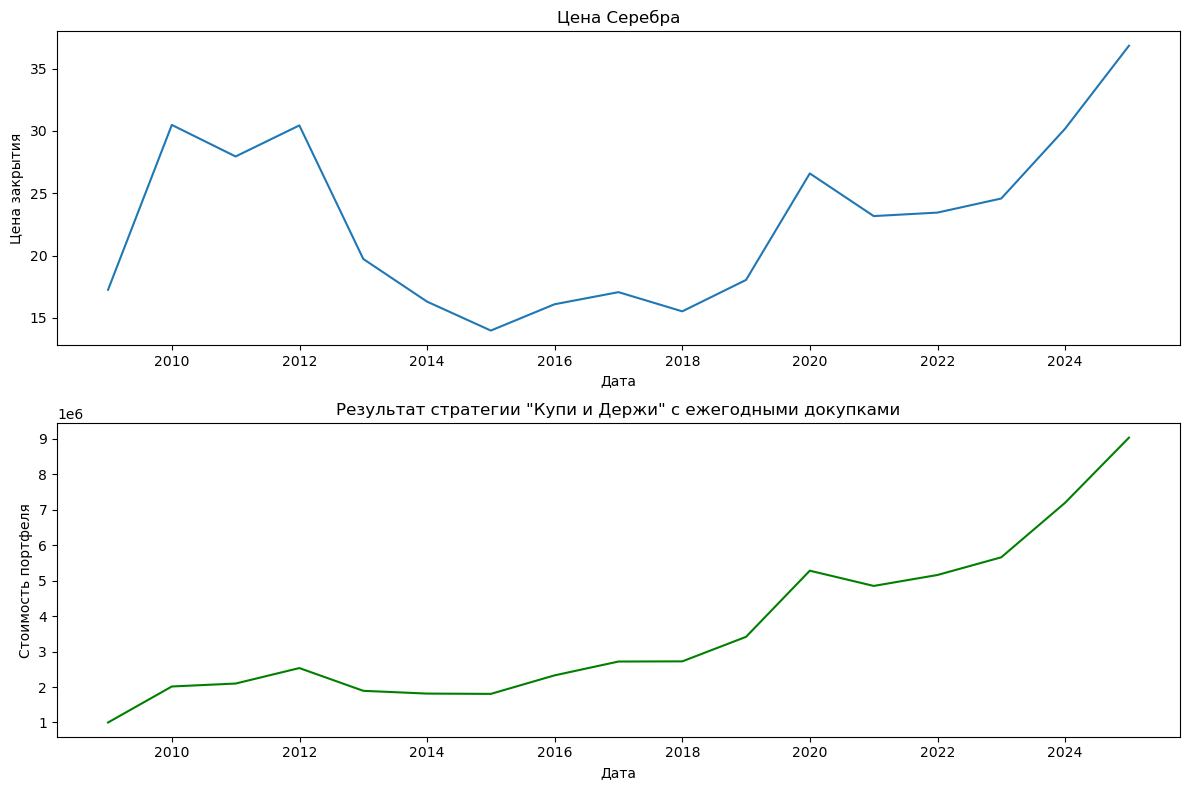

In [39]:
# Подготовка данных
silv_Y = silv_df_1m.resample('YE', closed='left', label='left').agg({'open' : 'first', 'high' : 'max', 'low' : 'min', 'close' : 'last', 'volume' : 'sum'}).dropna()
silv_Y = silv_Y.reset_index()
years = silv_Y['time'].dt.year.max() - silv_Y['time'].dt.year.min()
silv_Y['year'] = silv_Y['time'].dt.year

# Логика стратегии
capital = 5_000_000
initial_investment = 1_000_000 # Начальная инвестиция
every_year_invest = int((capital - initial_investment) / years)
silv_Y['Year_Return'] = silv_Y['close'].pct_change() # Годовая доходность
silv_Y['Portfolio_Value'] = 1_000_000.0

for ind in silv_Y.index:
  if silv_Y['year'].loc[ind] != 2008:
    prev_value = silv_Y.loc[ind - 1, 'Portfolio_Value']
    year_return = silv_Y.loc[ind, 'Year_Return']
    silv_Y.loc[ind, 'Portfolio_Value'] = (1 + year_return) * prev_value + every_year_invest


# Визуализация
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

axes[0].plot(
    silv_Y['time'],
    silv_Y['close'])

axes[0].set_title('Цена Серебра')
axes[0].set_ylabel('Цена закрытия')
axes[0].set_xlabel('Дата')

axes[1].plot(
    silv_Y['time'],
    silv_Y['Portfolio_Value'],
    color='green'
)
axes[1].set_title('Результат стратегии "Купи и Держи" с ежегодными докупками')
axes[1].set_ylabel('Стоимость портфеля')
axes[1].set_xlabel('Дата');
plt.tight_layout()


# Общая информация о стратегии
final_value = silv_Y['Portfolio_Value'].iloc[-1]
total_return = (final_value - initial_investment) / initial_investment * 100
CAGR = (final_value / initial_investment)**(1/years) - 1

print(f"Начальные инвестиции: {initial_investment:,.0f} руб")
print(f"Конечная стоимость: {final_value:,.0f} руб")
print(f"Общая доходность: {total_return:.2f}%")
print(f'Среднегодовая доходность: {(CAGR *100):.2f}%')

**Реализуем стратегию купи и держи с ежемесячными докупками**

Начальные инвестиции: 1,000,000 руб
Конечная стоимость: 10,111,701 руб
Общая доходность: 911.17%
Среднегодовая доходность: 15.56%


,time,open,high,low,close,volume,month,Year_Return,Portfolio_Value
0,2008-12-31,11.34,12.69,10.46,12.69,5647,12,NaN,1.000000e+06
1,2009-01-31,12.42,14.58,12.20,13.12,6545,1,0.033885,1.054087e+06
2,2009-02-28,13.30,13.96,11.99,13.06,9837,2,-0.004573,1.069468e+06
3,2009-03-31,13.12,13.29,11.80,12.82,6184,3,-0.018377,1.070017e+06
4,2009-04-30,12.75,15.68,12.27,15.65,3919,4,0.220749,1.326424e+06
...,...,...,...,...,...,...,...,...,...
194,2025-02-28,31.62,35.59,31.24,35.07,4683563,2,0.109108,9.547319e+06
195,2025-03-31,35.23,35.41,29.76,33.37,6243169,3,-0.048474,9.104720e+06
196,2025-04-30,33.28,33.93,32.01,33.13,3610049,4,-0.007192,9.059440e+06
197,2025-05-31,33.29,37.60,33.29,36.67,5062430,5,0.106852,1.004766e+07


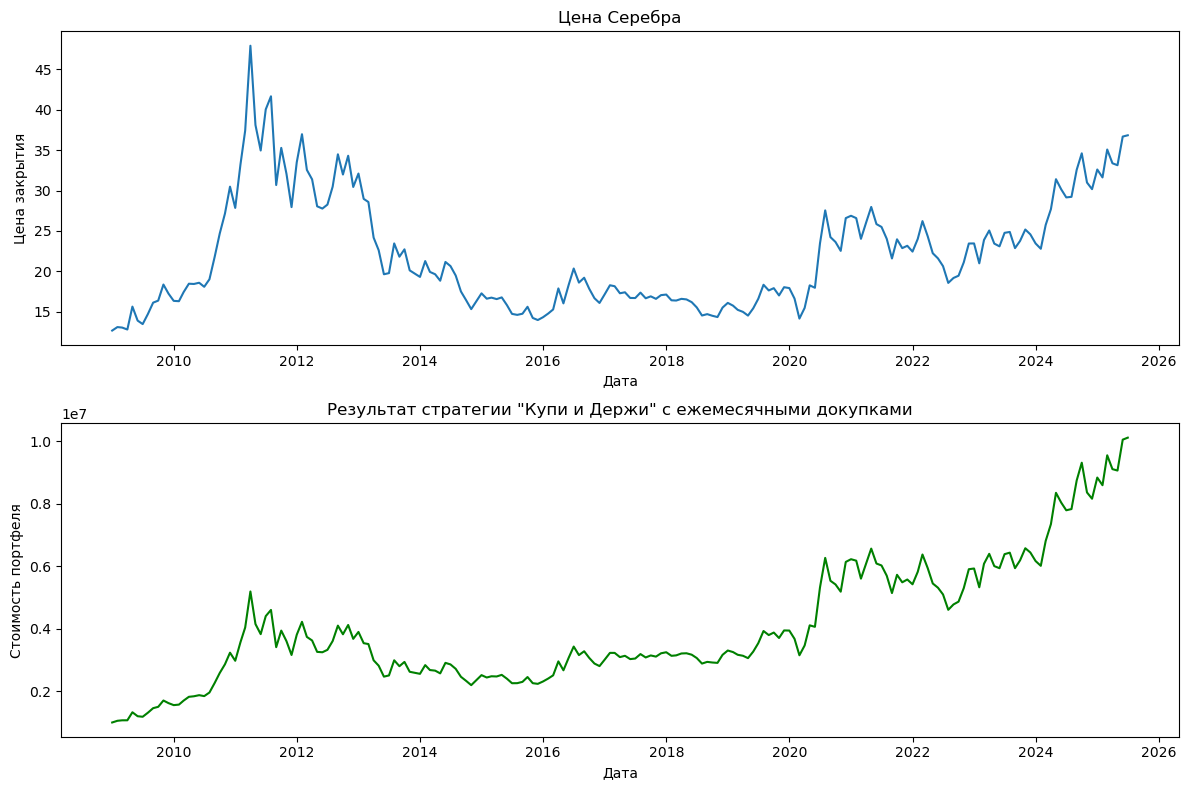

In [40]:
silv_1M = silv_df_1m.resample('ME', closed='left', label='left').agg({'open' : 'first', 'high' : 'max', 'low' : 'min', 'close' : 'last', 'volume' : 'sum'}).dropna()
silv_1M = silv_1M.reset_index()
end_date = silv_1M['time'].iloc[-1]
start_date = silv_1M['time'].iloc[0]
months_diff = (end_date.year - start_date.year) * 12 + (end_date.month - start_date.month)

silv_1M['month'] = silv_1M['time'].dt.month
capital = 5_000_000
initial_investment = 1_000_000 # Начальная инвестиция
every_year_invest = (capital - initial_investment) / months_diff
silv_1M['Year_Return'] = silv_1M['close'].pct_change() # Годовая доходность
# Первая инвестиция
silv_1M['Portfolio_Value'] = 1_000_000.0

for ind in silv_1M.index:
  if ind != 0:
    prev_value = silv_1M.loc[ind - 1, 'Portfolio_Value']
    year_return = silv_1M.loc[ind, 'Year_Return']
    silv_1M.loc[ind, 'Portfolio_Value'] = (1 + year_return) * prev_value + every_year_invest

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

axes[0].plot(
    silv_1M['time'],
    silv_1M['close'])

axes[0].set_title('Цена Серебра')
axes[0].set_ylabel('Цена закрытия')
axes[0].set_xlabel('Дата')

axes[1].plot(
    silv_1M['time'],
    silv_1M['Portfolio_Value'],
    color='green'
)
axes[1].set_title('Результат стратегии "Купи и Держи" с ежемесячными докупками')
axes[1].set_ylabel('Стоимость портфеля')
axes[1].set_xlabel('Дата');
plt.tight_layout()
final_value = silv_1M['Portfolio_Value'].iloc[-1]
total_return = (final_value - initial_investment) / initial_investment * 100
CAGR = (final_value / initial_investment)**(1/years) - 1

print(f"Начальные инвестиции: {initial_investment:,.0f} руб")
print(f"Конечная стоимость: {final_value:,.0f} руб")
print(f"Общая доходность: {total_return:.2f}%")
print(f'Среднегодовая доходность: {(CAGR *100):.2f}%')
display(silv_1M)

# 3. Универсальная стратегия "Купи и Держи+" с DCA

## Основные параметры стратегии

**Доступные варианты реализации:**
1. **Классическая "Купи и Держи"**  
   - Единоразовая покупка актива  
   - Долгосрочное удержание позиции  
   - Минимальное количество сделок  

2. **С ежегодными докупками**  
   - Первоначальная инвестиция 20-50% капитала  
   - Равномерные ежегодные докупки оставшейся суммы  
   - Оптимально для 5+ летних горизонтов  

3. **С ежеквартальными докупками**  
   - Докупаем актив каждые 3 месяца  
   - Эффективное усреднение цены  
   - Баланс между частотой и комиссиями  

4. **С ежемесячными докупками**  
   - Системные покупки 1-го числа каждого месяца  
   - Максимальное сглаживание цены входа  
   - Подходит для регулярных доходов (зарплата)  

5. **С еженедельными докупками**  
   - Покупка каждый понедельник/пятницу  
   - Точное следование рыночным колебаниям  
   - Требует низких комиссий  

## Ключевые параметры

**Размер капитала:**  
- Общая сумма для инвестирования  
- Рекомендуемый диапазон: от 100,000 руб  

**Размер первоначальной покупки (%):**  
- Доля капитала для первой покупки (20-50%)  
- Остаток распределяется на докупки  

**Комиссия за сделку:**  
- Учитывается при каждой покупке  
- Типовые значения: 0.05-0.3%  

## Преимущества подхода

✔ **Универсальность:** Один алгоритм для всех стратегий  
✔ **Гибкость:** Настройка под любой инвестиционный стиль  
✔ **Прозрачность:** Четкие правила входа  
✔ **Адаптивность:** Подбор частоты под рыночные условия  


> 💡 **Оптимальный выбор:** Для большинства инвесторов лучший баланс дают ежеквартальные и ежемесячные докупки - они сочетают хорошее усреднение цены с разумными комиссиями.

## Рекомендации по использованию

- **Консервативным инвесторам:** Годовые/квартальные докупки  
- **Активным инвесторам:** Месячные/недельные докупки  
- **Крипторынки:** Более частые докупки (неделя/месяц)  
- **Акции/ETF:** Квартальные/годовые интервалы  

**Важно:** Частые докупки требуют низких комиссий для сохранения эффективности стратегии.

Начальные инвестиции: 995,000 руб
Конечная стоимость: 9,924,364 руб
Общая доходность стратегии: 897.42%
Общая доходность актива: 282.01%
Среднегодовая доходность стратегии: 14.49%
Среднегодовая доходность актива: 6.29%


,time,open,high,low,close,volume,every_period_return,portfolio_value
0,2008-12-31,11.34,14.58,10.46,13.06,22029,NaN,9.950000e+05
1,2009-03-31,13.12,16.20,11.80,13.92,12083,0.065850,1.120898e+06
2,2009-06-30,14.12,17.61,12.51,16.14,11926,0.159483,1.360040e+06
3,2009-09-30,16.34,19.39,15.97,17.26,23645,0.069393,1.514794e+06
4,2009-12-31,18.85,18.95,15.05,17.45,39589,0.011008,1.591847e+06
...,...,...,...,...,...,...,...,...
62,2024-06-30,30.14,33.61,27.11,32.57,17504420,0.080265,8.548172e+06
63,2024-09-30,32.53,35.75,29.46,30.17,20216163,-0.073687,7.978656e+06
64,2024-12-31,30.75,35.59,30.37,35.07,14942489,0.162413,9.334871e+06
65,2025-03-31,35.23,37.60,29.76,36.67,14915648,0.045623,9.821134e+06


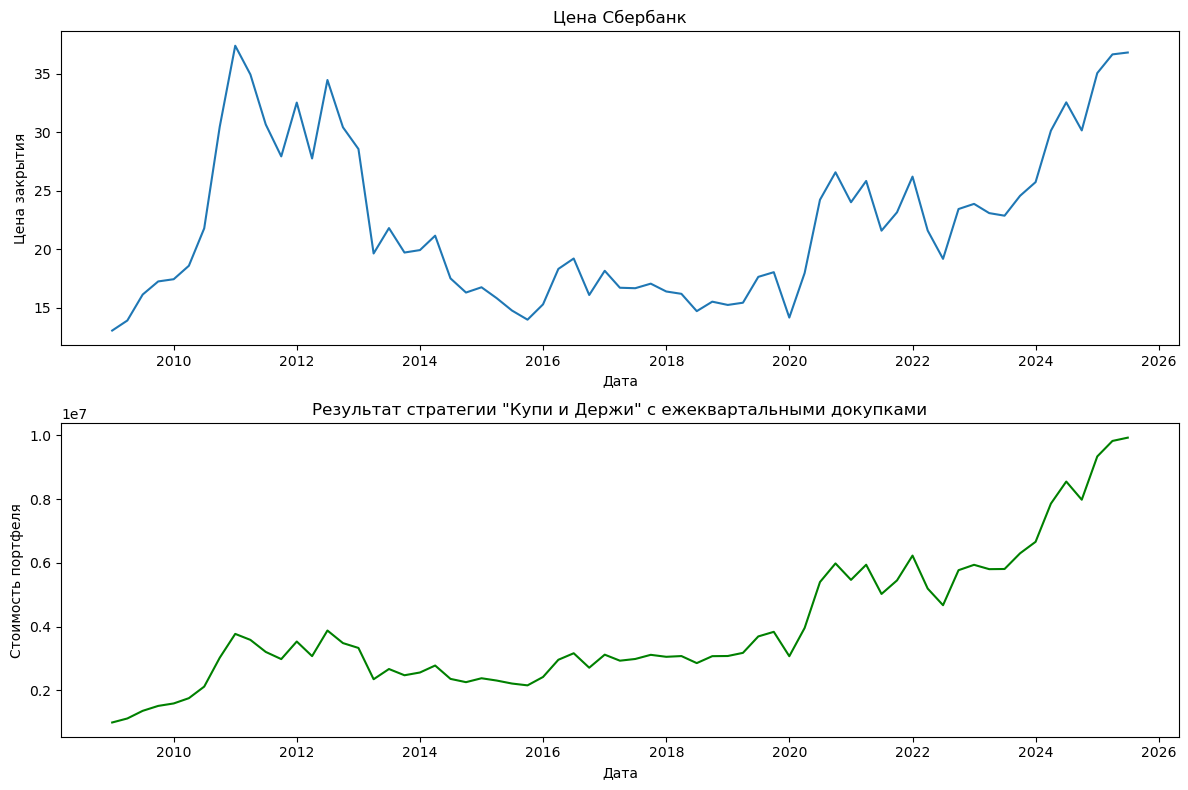

In [41]:
def strategy_buy_and_hold(data, capital=1_000_000, initial_purchases_ratio=20, commission=False, additional_purchase='YS', name_of_asset='актива'):
    """
    Реализация стратегии Buy and Hold с возможностью периодических докупок
    
    Args:
        data (DataFrame): Исходные данные с ценами
        capital (float): Начальный капитал. Defaults to 1_000_000.
        initial_purchases_ratio (float): Доля капитала для первоначальной покупки (0-1). Defaults to 0.2.
        commission (float): Комиссия в долях единицы (0.01 = 1%). Defaults to 0.0.
        additional_purchase (str): Частота докупок:
            'YS' - ежегодно (начало года)
            'Q' - ежеквартально
            'ME' - ежемесячно
            'W-MON' - еженедельно (по понедельникам)
            False - без докупок. Defaults to 'YS'.
    
    Returns:
        DataFrame: Результаты стратегии с деталями сделок
    """
    
    # 1. Обработка данных
    def good_dataframe(data):
        data.drop(['<TICKER>', '<PER>'], inplace=True, axis=1)
        data.columns = ['date', 'time', 'open', 'high', 'low', 'close', 'volume']
        data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
        data['time'] = pd.to_datetime(data['time'], format='%H%M%S')
        data['time'] = data['time'].dt.time
        data['time'] = pd.to_datetime(data['date'].astype('str') + ' '+ data['time'].astype('str'))
        data.drop(['date'], inplace=True, axis=1)
        data = data.set_index('time')
        
        return data
    
    new_data = good_dataframe(data)
    
    # 2. Определяем необходимый датафрейм
    new_data = new_data.resample(additional_purchase, closed='left', label='left').agg({'open' : 'first', 'high' : 'max', 'low' : 'min', 'close' : 'last', 'volume' : 'sum'}).dropna()
    
    # 3. Определяем количество докупок
    end_date = new_data.index[-1]  
    start_date = new_data.index[0]
    years = end_date.year-start_date.year
    diff = len(new_data) - 1
    
    if additional_purchase == 'YS':
        name_of_period = 'ежегодными'
        
    elif additional_purchase == 'QE':
        name_of_period = 'ежеквартальными'
        
    elif additional_purchase == 'ME':
        name_of_period = 'ежемесячными'
        
    elif additional_purchase == 'W-MON':
        name_of_period = 'еженедельными'
        
    
    # 4. Первоначальные данные
    new_data['every_period_return'] = new_data['close'].pct_change() # Доходность за период
    new_data = new_data.reset_index()



    # 5. Алгоритм стратегии
    # 5.1 Работаем с докупкой
    if additional_purchase: # Если работаем с докупкой
        
        if commission: # Если с комиссией
            initial_investment = (capital * (initial_purchases_ratio / 100)) * (1 - commission) # Первая покупка
            new_data['portfolio_value'] = initial_investment
            
        else: # Если без комиссии
            initial_investment = (capital * (initial_purchases_ratio / 100)) # Первая покупка
            new_data['portfolio_value'] = initial_investment
            
        every_period_invest = int((capital - initial_investment) / diff)

        for ind in new_data.index[1:]: # Алгоритм докупки раз в период
            
            prev_value = new_data.loc[ind - 1, 'portfolio_value']
            period_return = new_data.loc[ind, 'every_period_return']
            
            if commission:
                new_data.loc[ind, 'portfolio_value'] = (1 + period_return) * (prev_value) + every_period_invest * (1 - commission)
                
            else:
                new_data.loc[ind, 'portfolio_value'] = (1 + period_return) * (prev_value) + every_period_invest
    # 5.2 Работаем без докупки           
    else: 
        # Первая покупка
        if commission: # Если с комиссией
            new_data['portfolio_value'] = capital * (1 - commission)
        # Первая покупка   
        else: # Если без комиссии
            new_data['portfolio_value'] = capital
            
        for ind in new_data.index[1:]:
            prev_value = new_data.loc[ind - 1, 'portfolio_value']
            period_return = new_data.loc[ind, 'every_period_return']
            new_data.loc[ind, 'portfolio_value'] = (1 + period_return) * (prev_value)
            
        
    # 6. График актива и доходность
    
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

    axes[0].plot(
        new_data['time'],
        new_data['close'])

    axes[0].set_title(f'Цена {name_of_asset}')
    axes[0].set_ylabel('Цена закрытия')
    axes[0].set_xlabel('Дата')

    axes[1].plot(
        new_data['time'],
        new_data['portfolio_value'],
        color='green')
    
    axes[1].set_title(f'Результат стратегии "Купи и Держи" с {name_of_period} докупками')
    axes[1].set_ylabel('Стоимость портфеля')
    axes[1].set_xlabel('Дата');
    
    plt.tight_layout()
    
    
    
    
    # 7. Общая информация о результатах стратегии
    
    final_value = new_data['portfolio_value'].iloc[-1] # Стоимость портфеля на конец периода
    total_return_strategy = (final_value - initial_investment) / initial_investment * 100 # Общая доходность стратегии
    CAGR_strategry = (final_value / initial_investment)**(1 / years) - 1 # Среднегодовая доходность стратегии
    total_return_asset = new_data['close'].iloc[-1] / new_data['close'].iloc[0] * 100 # Общая доходность актива
    CAGR_asset = (new_data['close'].iloc[-1] / new_data['close'].iloc[0])**(1 / years) - 1 # Среднегодовая доходность актива

    print(f"Начальные инвестиции: {initial_investment:,.0f} руб")
    print(f"Конечная стоимость: {final_value:,.0f} руб")
    print(f"Общая доходность стратегии: {total_return_strategy:.2f}%")
    print(f"Общая доходность актива: {total_return_asset:.2f}%")
    print(f'Среднегодовая доходность стратегии: {(CAGR_strategry *100):.2f}%')
    print(f'Среднегодовая доходность актива: {(CAGR_asset*100):.2f}%')



        
    

    return new_data

silv = pd.read_csv('data/SILV.txt')
result= strategy_buy_and_hold(silv, capital=5_000_000, initial_purchases_ratio=20, additional_purchase='QE', commission=0.005, name_of_asset='Сбербанк')
display(result)
